傾き = -0.3950978927188636
平均寿命 = 2.5310183081932087 μs


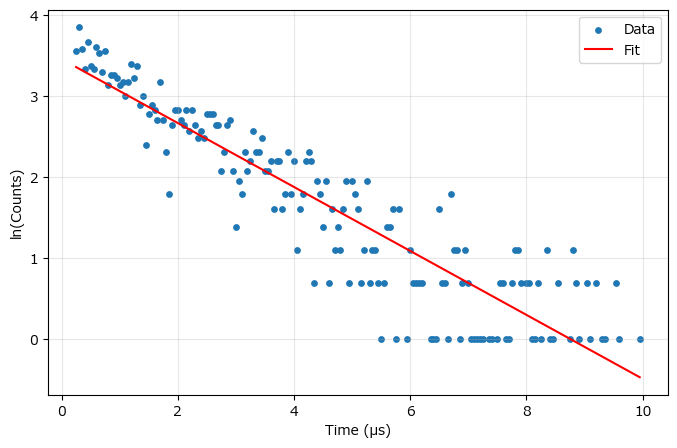

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# 測定データをここに貼る
counts = np.array([
2514,299,49,34,38,35,47,36,28,39,29,28,37,34,27,35,
23,26,26,25,23,24,20,24,30,25,29,18,20,11,16,18,
17,15,24,15,10,6,14,17,17,15,14,17,13,17,14,12,
13,12,16,16,16,14,14,8,10,14,15,8,4,7,6,10,
8,9,13,10,10,12,8,8,9,5,9,9,5,6,10,6,
9,3,5,6,9,10,9,2,7,6,4,7,2,5,3,4,
3,5,7,2,7,6,5,2,3,7,2,3,3,2,1,2,
4,4,5,1,5,0,0,1,3,2,2,2,2,0,0,1,
1,1,5,2,2,1,6,3,3,1,2,3,2,1,1,1,
1,1,0,1,1,0,1,2,2,1,1,2,3,3,2,0,
2,2,1,1,2,1,0,3,1,1,0,2,0,0,0,1,
3,2,1,0,0,2,1,0,2,0,1,1,0,0,0,2,
1,0,0,0,0,0,0,1,0,0,0,1,0,0,0,2,
1,0,0,0,1,1,0,1,0,0,1,1,0,0,0,2,
0,1,0,0,0,3,0,1,0,0,1,0,0,1,1,0,
2,0,1,0,0,1,0,0,0,1,0,0,0,0,0,1
])

# 1ビン = 0.1 μs (必要なら変更)
dt = 0.05

t = np.arange(len(counts)) * dt

from scipy.stats import linregress

mask = (counts > 0) & (t > 0.2) & (t < 10)

result = linregress(t[mask], np.log(counts[mask]))

a = result.slope
b = result.intercept

tau = -1 / a

print("傾き =", a)
print("平均寿命 =", tau, "μs")

plt.figure(figsize=(8,5))
plt.scatter(t[mask], np.log(counts[mask]), s=15, label="Data")
plt.plot(t[mask], a*t[mask]+b, 'r', label="Fit")
plt.xlabel("Time (μs)")
plt.ylabel("ln(Counts)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()



傾き = -0.4969
平均寿命 τ = 2.013 μs
R² = 0.8880


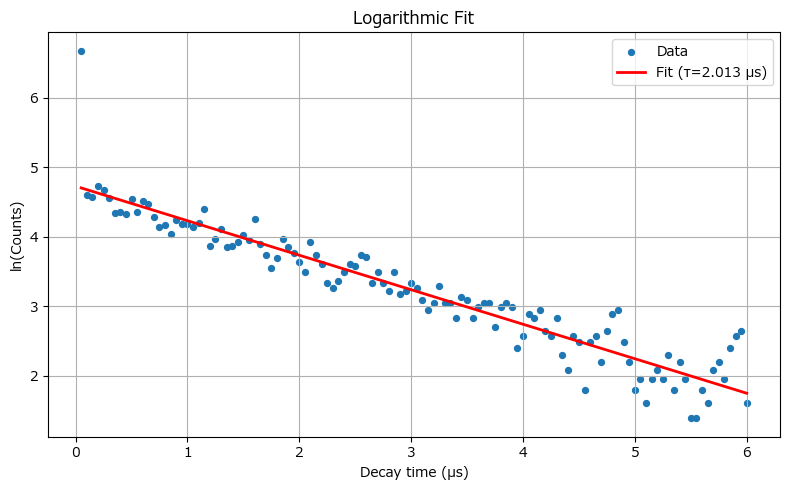

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

# ======== データ ========
counts = np.array([
6641,796,100,97,114,107,95,77,78,76,94,78,92,87,73,63,
65,57,70,66,66,63,67,82,48,53,61,47,48,51,56,52,
71,49,42,35,40,53,47,43,38,33,51,42,37,28,26,29,
33,37,36,42,41,28,33,28,25,33,24,25,28,26,22,19,
21,27,21,21,17,23,22,17,20,21,21,15,20,21,20,11,
13,18,17,19,14,13,17,10,8,13,12,6,12,13,9,14,
18,19,12,9,6,7,5,7,8,7,10,6,9,7,4,4,
6,5,8,9,7,11,13,14,5,9,3,3,9,7,6,4,
5,6,7,5,7,5,6,9,5,4,2,3,5,2,3,3,
6,3,4,5,8,5,4,6,1,3,3,7,3,6,3,3,
2,0,6,3,2,5,1,0,10,2,1,1,4,1,2,2,
3,2,3,0,2,0,1,5,0,2,1,2,2,1,3,0,
6,0,1,2,1,0,0,3,0,2,0,0,2,2,2,0,
1,1,4,3,2,1,0,0,0,2,3,2,0,0,2,1,
0,2,1,2,1,3,5,1,2,1,3,2,1,1,0,0,
0,1,2,0,0,0,1,2,0,0,2,2,1,1,1,2
])

# ======== 時間軸 ========
dt = 0.05  # μs（50 ns）
t = np.arange(len(counts)) * dt


# ======== フィッティング ========
# 最初のビン(6641)は除外
mask = (counts > 0) & (t >= 0.05) & (t <= 6.0)

x = t[mask]
y = np.log(counts[mask])

result = linregress(x, y)

a = result.slope
b = result.intercept
tau = -1 / a

print(f"傾き = {a:.4f}")
print(f"平均寿命 τ = {tau:.3f} μs")
print(f"R² = {result.rvalue**2:.4f}")

# ======== 対数プロット ========
plt.figure(figsize=(8,5))
plt.scatter(x, y, s=18, label="Data")
plt.plot(x, a*x+b, "r", lw=2,
         label=f"Fit (τ={tau:.3f} μs)")
plt.xlabel("Decay time (μs)")
plt.ylabel("ln(Counts)")
plt.title("Logarithmic Fit")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

傾き = -0.5073
平均寿命 τ = 1.971 μs
R² = 0.8969


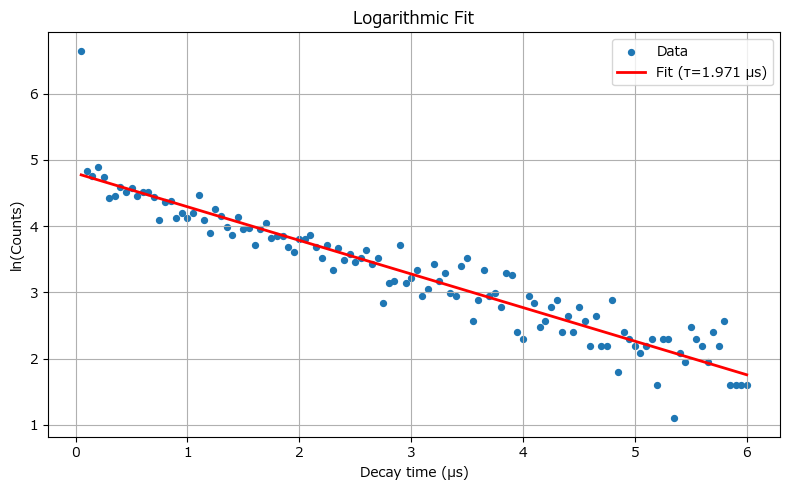

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress


counts = np.array([
6511,772,125,116,133,114,84,86,98,91,97,86,92,91,85,60,
79,80,62,67,62,67,88,60,49,71,64,54,48,63,52,53,
41,52,57,46,47,47,40,37,45,45,48,40,34,41,28,39,
33,36,32,34,38,31,34,17,23,24,41,23,25,28,19,21,
31,24,27,20,19,30,34,13,18,28,19,20,16,27,26,11,
10,19,17,12,13,16,18,11,14,11,16,13,9,14,9,9,
18,6,11,10,9,8,9,10,5,10,10,3,8,7,12,10,
9,7,11,9,13,5,5,5,5,7,7,3,10,7,7,6,
8,6,6,3,4,5,6,7,4,6,3,7,6,2,1,3,
7,2,3,6,3,9,6,3,3,3,3,4,5,3,1,2,
2,1,2,4,2,0,7,5,2,2,3,3,1,2,0,1,
0,2,2,2,0,2,2,2,2,3,4,1,2,1,0,2,
2,3,2,1,1,4,1,2,1,0,1,1,2,1,2,1,
1,2,2,0,1,3,0,1,1,1,2,4,0,1,3,1,
0,0,0,2,0,1,2,1,1,1,1,0,0,0,2,2,
0,0,3,1,1,1,1,1,0,1,1,2,0,0,0,0
])



# ======== 時間軸 ========
dt = 0.05  # μs（50 ns）
t = np.arange(len(counts)) * dt


# ======== フィッティング ========
# 最初のビン(6641)は除外
mask = (counts > 0) & (t >= 0.05) & (t <= 6.0)

x = t[mask]
y = np.log(counts[mask])

result = linregress(x, y)

a = result.slope
b = result.intercept
tau = -1 / a

print(f"傾き = {a:.4f}")
print(f"平均寿命 τ = {tau:.3f} μs")
print(f"R² = {result.rvalue**2:.4f}")

# ======== 対数プロット ========
plt.figure(figsize=(8,5))
plt.scatter(x, y, s=18, label="Data")
plt.plot(x, a*x+b, "r", lw=2,
         label=f"Fit (τ={tau:.3f} μs)")
plt.xlabel("Decay time (μs)")
plt.ylabel("ln(Counts)")
plt.title("Logarithmic Fit")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

傾き = -0.4820
平均寿命 τ = 2.075 μs
R² = 0.9036


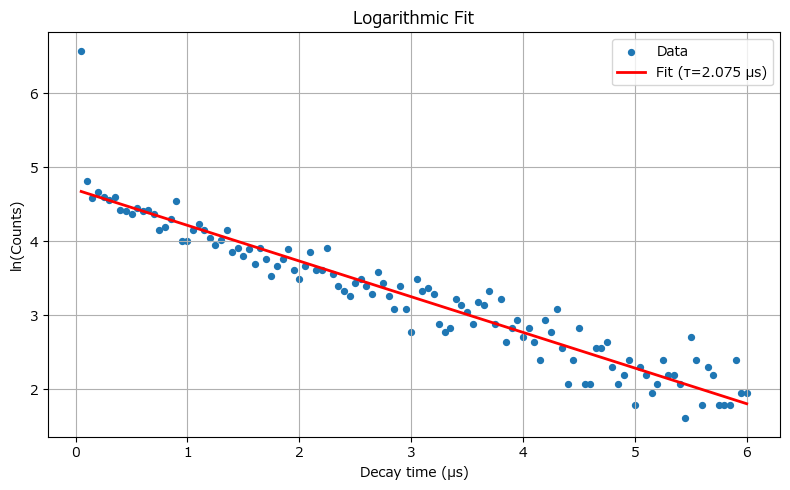

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress


counts = np.array([
6351,718,124,98,106,99,95,99,84,82,79,86,82,84,79,64,
66,74,94,55,55,64,69,64,57,52,56,64,47,50,45,49,
40,50,43,34,39,43,49,37,33,39,47,37,37,50,35,30,
28,26,31,33,30,27,36,31,26,22,30,22,16,33,28,29,
27,18,16,17,25,23,21,18,24,23,28,18,25,14,17,19,
15,17,14,11,19,16,22,13,8,11,17,8,8,13,13,14,
10,8,9,11,6,10,9,7,8,11,9,9,8,5,15,11,
6,10,9,6,6,6,11,7,7,6,2,5,8,13,4,8,
5,1,6,3,7,3,2,7,4,3,4,6,3,4,4,4,
0,3,4,3,5,5,4,1,4,4,3,4,6,3,1,0,
5,3,1,1,2,4,0,2,2,2,2,2,1,4,2,2,
0,5,1,1,2,1,6,2,1,2,2,2,0,1,0,0,
2,4,1,1,1,2,4,1,6,4,0,1,3,4,4,0,
1,3,1,0,2,2,0,5,0,0,2,2,3,0,1,0,
1,1,0,4,3,1,1,4,1,3,2,2,0,2,1,3,
2,3,1,1,1,0,0,0,2,1,1,2,1,4,1,1
])



# ======== 時間軸 ========
dt = 0.05  # μs（50 ns）
t = np.arange(len(counts)) * dt


# ======== フィッティング ========
# 最初のビン(6641)は除外
mask = (counts > 0) & (t >= 0.05) & (t <= 6.0)

x = t[mask]
y = np.log(counts[mask])

result = linregress(x, y)

a = result.slope
b = result.intercept
tau = -1 / a

print(f"傾き = {a:.4f}")
print(f"平均寿命 τ = {tau:.3f} μs")
print(f"R² = {result.rvalue**2:.4f}")

# ======== 対数プロット ========
plt.figure(figsize=(8,5))
plt.scatter(x, y, s=18, label="Data")
plt.plot(x, a*x+b, "r", lw=2,
         label=f"Fit (τ={tau:.3f} μs)")
plt.xlabel("Decay time (μs)")
plt.ylabel("ln(Counts)")
plt.title("Logarithmic Fit")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

傾き = -0.4900
平均寿命 τ = 2.041 μs
R² = 0.8951


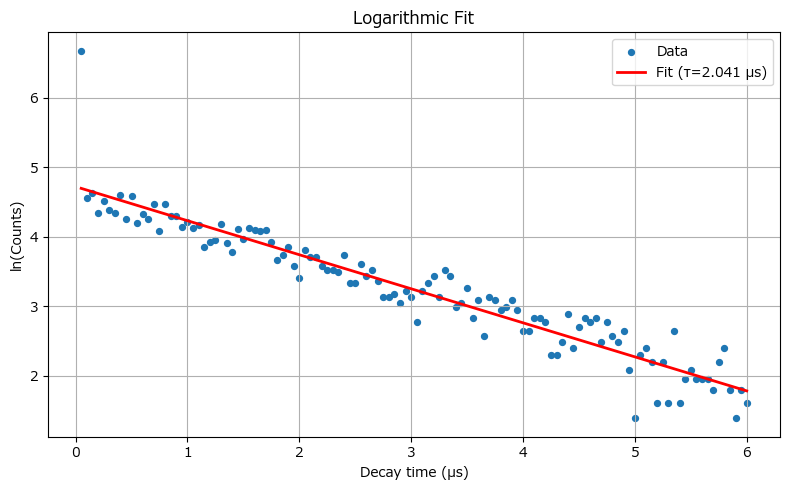

傾き = -0.4900
平均寿命 τ = 2.041 μs
R² = 0.8951


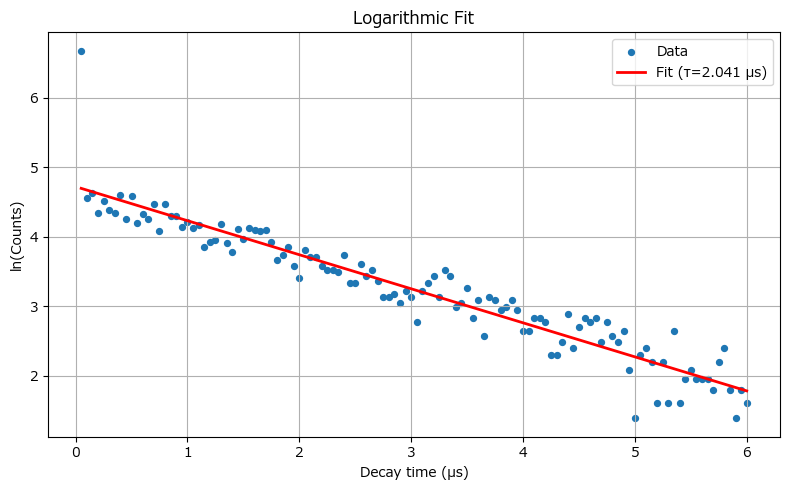

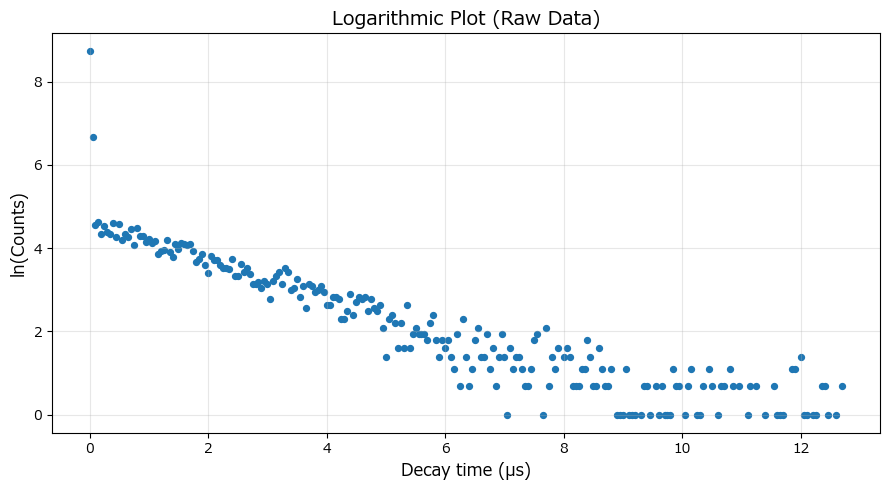

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress


counts = np.array([
6170,795,96,103,77,92,80,77,99,71,98,67,76,71,87,59,
88,74,74,63,68,62,65,47,51,52,66,50,44,61,53,62,
60,59,60,51,39,42,47,36,30,45,41,41,36,34,34,33,
42,28,28,37,31,34,29,23,23,24,21,25,23,16,25,28,
31,23,34,31,20,21,26,17,22,13,23,22,19,20,22,19,
14,14,17,17,16,10,10,12,18,11,15,17,16,17,12,16,
13,12,14,8,4,10,11,9,5,9,5,14,5,7,8,7,
7,7,6,9,11,6,4,6,5,6,4,3,7,2,10,4,
2,3,6,8,4,4,7,3,5,2,4,7,4,1,5,3,
4,4,3,2,2,3,6,7,0,1,8,2,4,3,5,0,
4,5,4,2,2,2,3,3,6,4,2,2,5,3,2,2,
3,0,1,1,1,3,1,1,1,0,1,2,2,1,0,2,
1,2,1,1,1,3,2,2,0,1,2,3,0,1,1,2,
0,3,2,0,1,2,2,0,3,2,0,2,0,0,1,2,
0,2,0,0,1,0,0,2,1,1,1,0,0,3,3,0,
4,1,1,0,1,1,0,2,2,1,0,0,1,0,2,0
])



# ======== 時間軸 ========
dt = 0.05  # μs（50 ns）
t = np.arange(len(counts)) * dt


# ======== フィッティング ========
# 最初のビン(6641)は除外
mask = (counts > 0) & (t >= 0.05) & (t <= 6.0)

x = t[mask]
y = np.log(counts[mask])

result = linregress(x, y)

a = result.slope
b = result.intercept
tau = -1 / a

print(f"傾き = {a:.4f}")
print(f"平均寿命 τ = {tau:.3f} μs")
print(f"R² = {result.rvalue**2:.4f}")

# ======== 対数プロット ========
plt.figure(figsize=(8,5))
plt.scatter(x, y, s=18, label="Data")
plt.plot(x, a*x+b, "r", lw=2,
         label=f"Fit (τ={tau:.3f} μs)")
plt.xlabel("Decay time (μs)")
plt.ylabel("ln(Counts)")
plt.title("Logarithmic Fit")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

import numpy as np
import matplotlib.pyplot as plt

dt = 0.05
t = np.arange(len(counts))*dt

plt.figure(figsize=(9,5))

# log(0)は計算できないため、0だけ除外
mask = counts > 0

plt.scatter(t[mask], np.log(counts[mask]), s=18)

plt.xlabel("Decay time (μs)", fontsize=12)
plt.ylabel("ln(Counts)", fontsize=12)
plt.title("Logarithmic Plot (Raw Data)", fontsize=14)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

傾き = -0.40430
平均寿命 τ = 2.473 μs


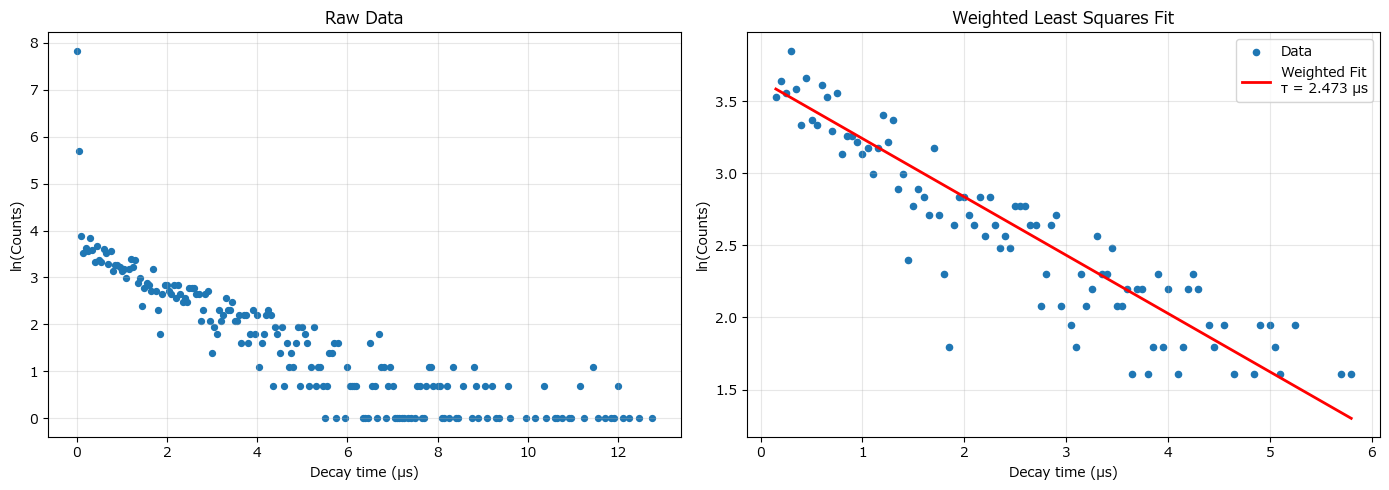

In [20]:
import numpy as np
import matplotlib.pyplot as plt

# 6/24
counts = np.array([
2514,299,49,34,38,35,47,36,28,39,29,28,37,34,27,35,
23,26,26,25,23,24,20,24,30,25,29,18,20,11,16,18,
17,15,24,15,10,6,14,17,17,15,14,17,13,17,14,12,
13,12,16,16,16,14,14,8,10,14,15,8,4,7,6,10,
8,9,13,10,10,12,8,8,9,5,9,9,5,6,10,6,
9,3,5,6,9,10,9,2,7,6,4,7,2,5,3,4,
3,5,7,2,7,6,5,2,3,7,2,3,3,2,1,2,
4,4,5,1,5,0,0,1,3,2,2,2,2,0,0,1,
1,1,5,2,2,1,6,3,3,1,2,3,2,1,1,1,
1,1,0,1,1,0,1,2,2,1,1,2,3,3,2,0,
2,2,1,1,2,1,0,3,1,1,0,2,0,0,0,1,
3,2,1,0,0,2,1,0,2,0,1,1,0,0,0,2,
1,0,0,0,0,0,0,1,0,0,0,1,0,0,0,2,
1,0,0,0,1,1,0,1,0,0,1,1,0,0,0,2,
0,1,0,0,0,3,0,1,0,0,1,0,0,1,1,0,
2,0,1,0,0,1,0,0,0,1,0,0,0,0,0,1
])
# -------------------------
# 時間軸
# -------------------------
dt = 0.05   # μs (50 ns)
t = np.arange(len(counts)) * dt

# =========================
# フィット用データ
# =========================
mask = (counts >= 5) & (t >= 0.15) & (t <= 6.0)

x = t[mask]
y = np.log(counts[mask])

# 重み（Poisson統計）
w = np.sqrt(counts[mask])

# 重み付き最小二乗
coef = np.polyfit(x, y, 1, w=w)

a = coef[0]
b = coef[1]

tau = -1 / a

print(f"傾き = {a:.5f}")
print(f"平均寿命 τ = {tau:.3f} μs")

# =========================
# グラフ
# =========================
fig, ax = plt.subplots(1, 2, figsize=(14,5))

# -------------------------
# 左：除外なし
# -------------------------
mask_raw = counts > 0

ax[0].scatter(
    t[mask_raw],
    np.log(counts[mask_raw]),
    s=18
)

ax[0].set_title("Raw Data")
ax[0].set_xlabel("Decay time (μs)")
ax[0].set_ylabel("ln(Counts)")
ax[0].grid(alpha=0.3)

# -------------------------
# 右：フィット
# -------------------------
ax[1].scatter(
    x,
    y,
    s=20,
    label="Data"
)

xx = np.linspace(x.min(), x.max(), 200)

ax[1].plot(
    xx,
    a*xx+b,
    color="red",
    linewidth=2,
    label=f"Weighted Fit\nτ = {tau:.3f} μs"
)

ax[1].set_title("Weighted Least Squares Fit")
ax[1].set_xlabel("Decay time (μs)")
ax[1].set_ylabel("ln(Counts)")
ax[1].grid(alpha=0.3)
ax[1].legend()

plt.tight_layout()
plt.show()

傾き = -0.45922
平均寿命 τ = 2.178 μs


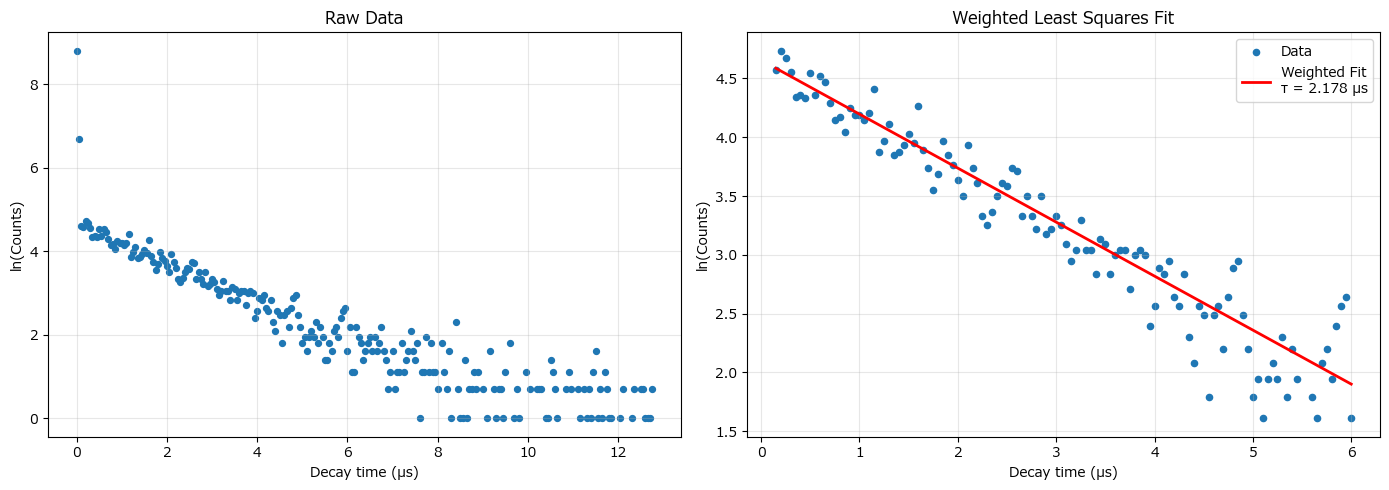

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# 6/25
counts = np.array([
6641,796,100,97,114,107,95,77,78,76,94,78,92,87,73,63,
65,57,70,66,66,63,67,82,48,53,61,47,48,51,56,52,
71,49,42,35,40,53,47,43,38,33,51,42,37,28,26,29,
33,37,36,42,41,28,33,28,25,33,24,25,28,26,22,19,
21,27,21,21,17,23,22,17,20,21,21,15,20,21,20,11,
13,18,17,19,14,13,17,10,8,13,12,6,12,13,9,14,
18,19,12,9,6,7,5,7,8,7,10,6,9,7,4,4,
6,5,8,9,7,11,13,14,5,9,3,3,9,7,6,4,
5,6,7,5,7,5,6,9,5,4,2,3,5,2,3,3,
6,3,4,5,8,5,4,6,1,3,3,7,3,6,3,3,
2,0,6,3,2,5,1,0,10,2,1,1,4,1,2,2,
3,2,3,0,2,0,1,5,0,2,1,2,2,1,3,0,
6,0,1,2,1,0,0,3,0,2,0,0,2,2,2,0,
1,1,4,3,2,1,0,0,0,2,3,2,0,0,2,1,
0,2,1,2,1,3,5,1,2,1,3,2,1,1,0,0,
0,1,2,0,0,0,1,2,0,0,2,2,1,1,1,2
])
# -------------------------
# 時間軸
# -------------------------
dt = 0.05   # μs (50 ns)
t = np.arange(len(counts)) * dt

# =========================
# フィット用データ
# =========================
mask = (counts >= 5) & (t >= 0.15) & (t <= 6.0)

x = t[mask]
y = np.log(counts[mask])

# 重み（Poisson統計）
w = np.sqrt(counts[mask])

# 重み付き最小二乗
coef = np.polyfit(x, y, 1, w=w)

a = coef[0]
b = coef[1]

tau = -1 / a

print(f"傾き = {a:.5f}")
print(f"平均寿命 τ = {tau:.3f} μs")

# =========================
# グラフ
# =========================
fig, ax = plt.subplots(1, 2, figsize=(14,5))

# -------------------------
# 左：除外なし
# -------------------------
mask_raw = counts > 0

ax[0].scatter(
    t[mask_raw],
    np.log(counts[mask_raw]),
    s=18
)

ax[0].set_title("Raw Data")
ax[0].set_xlabel("Decay time (μs)")
ax[0].set_ylabel("ln(Counts)")
ax[0].grid(alpha=0.3)

# -------------------------
# 右：フィット
# -------------------------
ax[1].scatter(
    x,
    y,
    s=20,
    label="Data"
)

xx = np.linspace(x.min(), x.max(), 200)

ax[1].plot(
    xx,
    a*xx+b,
    color="red",
    linewidth=2,
    label=f"Weighted Fit\nτ = {tau:.3f} μs"
)

ax[1].set_title("Weighted Least Squares Fit")
ax[1].set_xlabel("Decay time (μs)")
ax[1].set_ylabel("ln(Counts)")
ax[1].grid(alpha=0.3)
ax[1].legend()

plt.tight_layout()
plt.show()

傾き = -0.47619
平均寿命 τ = 2.100 μs


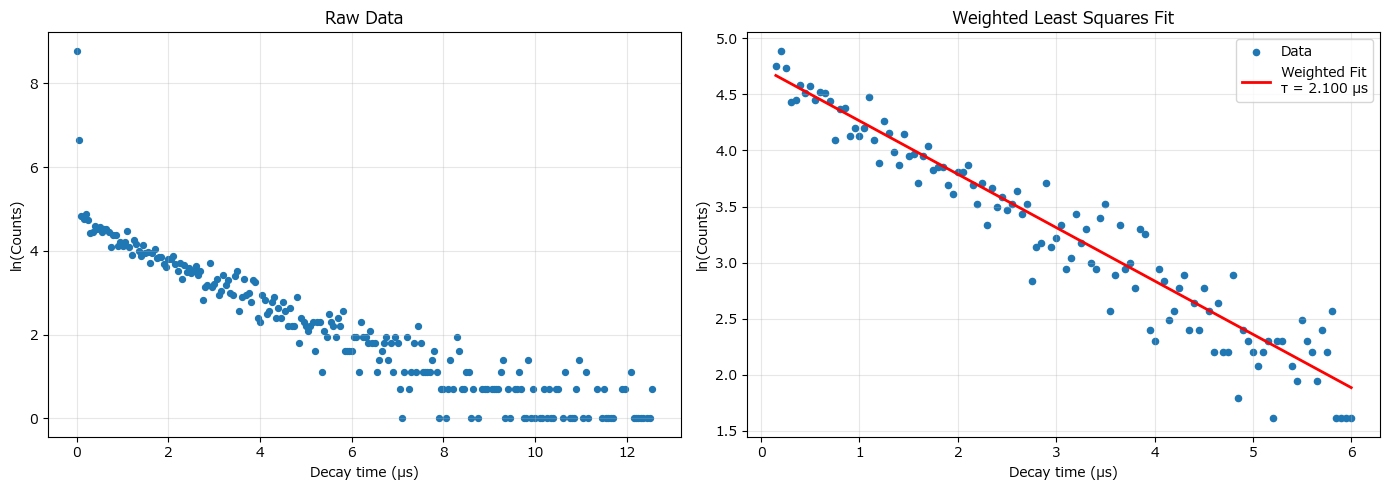

In [22]:
import numpy as np
import matplotlib.pyplot as plt

# 6/26
counts = np.array([
6511,772,125,116,133,114,84,86,98,91,97,86,92,91,85,60,
79,80,62,67,62,67,88,60,49,71,64,54,48,63,52,53,
41,52,57,46,47,47,40,37,45,45,48,40,34,41,28,39,
33,36,32,34,38,31,34,17,23,24,41,23,25,28,19,21,
31,24,27,20,19,30,34,13,18,28,19,20,16,27,26,11,
10,19,17,12,13,16,18,11,14,11,16,13,9,14,9,9,
18,6,11,10,9,8,9,10,5,10,10,3,8,7,12,10,
9,7,11,9,13,5,5,5,5,7,7,3,10,7,7,6,
8,6,6,3,4,5,6,7,4,6,3,7,6,2,1,3,
7,2,3,6,3,9,6,3,3,3,3,4,5,3,1,2,
2,1,2,4,2,0,7,5,2,2,3,3,1,2,0,1,
0,2,2,2,0,2,2,2,2,3,4,1,2,1,0,2,
2,3,2,1,1,4,1,2,1,0,1,1,2,1,2,1,
1,2,2,0,1,3,0,1,1,1,2,4,0,1,3,1,
0,0,0,2,0,1,2,1,1,1,1,0,0,0,2,2,
0,0,3,1,1,1,1,1,0,1,1,2,0,0,0,0
])
# -------------------------
# 時間軸
# -------------------------
dt = 0.05   # μs (50 ns)
t = np.arange(len(counts)) * dt

# =========================
# フィット用データ
# =========================
mask = (counts >= 5) & (t >= 0.15) & (t <= 6.0)

x = t[mask]
y = np.log(counts[mask])

# 重み（Poisson統計）
w = np.sqrt(counts[mask])

# 重み付き最小二乗
coef = np.polyfit(x, y, 1, w=w)

a = coef[0]
b = coef[1]

tau = -1 / a

print(f"傾き = {a:.5f}")
print(f"平均寿命 τ = {tau:.3f} μs")

# =========================
# グラフ
# =========================
fig, ax = plt.subplots(1, 2, figsize=(14,5))

# -------------------------
# 左：除外なし
# -------------------------
mask_raw = counts > 0

ax[0].scatter(
    t[mask_raw],
    np.log(counts[mask_raw]),
    s=18
)

ax[0].set_title("Raw Data")
ax[0].set_xlabel("Decay time (μs)")
ax[0].set_ylabel("ln(Counts)")
ax[0].grid(alpha=0.3)

# -------------------------
# 右：フィット
# -------------------------
ax[1].scatter(
    x,
    y,
    s=20,
    label="Data"
)

xx = np.linspace(x.min(), x.max(), 200)

ax[1].plot(
    xx,
    a*xx+b,
    color="red",
    linewidth=2,
    label=f"Weighted Fit\nτ = {tau:.3f} μs"
)

ax[1].set_title("Weighted Least Squares Fit")
ax[1].set_xlabel("Decay time (μs)")
ax[1].set_ylabel("ln(Counts)")
ax[1].grid(alpha=0.3)
ax[1].legend()

plt.tight_layout()
plt.show()

256
傾き a = -0.46786 ± 0.00890
切片 b = 6.39861 ± 0.01639
τ = 2.14 ± 0.04 μs


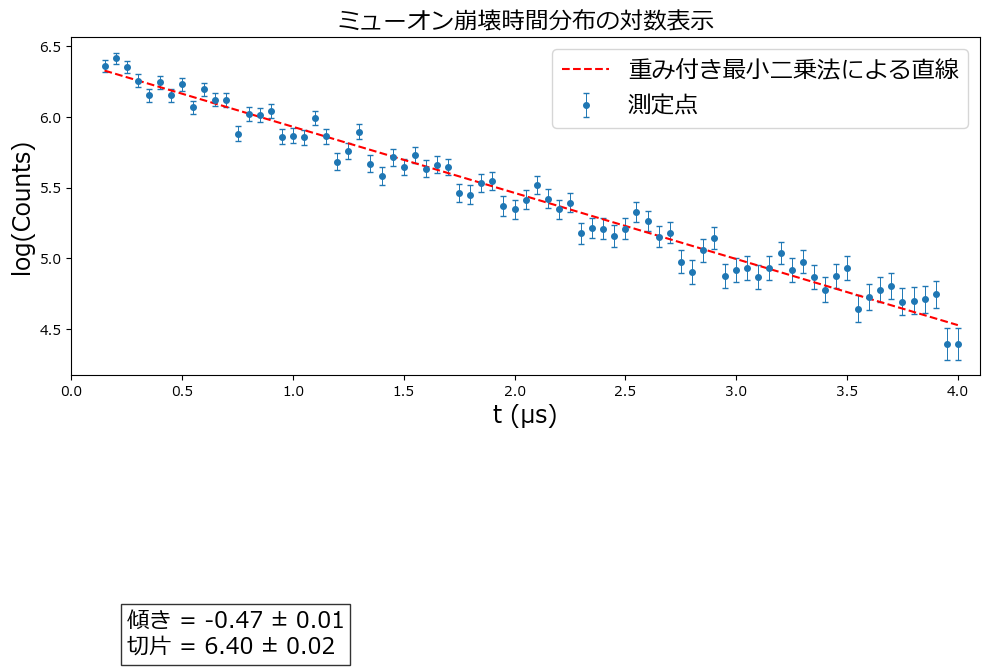

In [73]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# =====================
# 日本語フォント
# =====================

plt.rcParams["font.family"] = "Meiryo"

counts = np.array([
36453,4426,623,579,611,574,522,471,515,471,508,432,491,456,455,358,
413,409,420,351,353,349,400,352,294,318,363,290,266,303,283,308,
280,288,283,236,233,253,257,215,210,225,250,226,210,220,177,184,
183,174,183,206,193,173,178,145,135,157,171,131,137,139,130,139,
154,137,145,130,119,131,139,104,113,119,122,109,110,111,115,81,
81,92,90,85,88,79,94,60,67,68,87,65,63,76,62,76,
81,66,65,53,50,61,51,46,41,60,57,50,40,39,53,42,
40,45,51,46,49,34,41,41,33,32,22,18,42,33,33,31,
26,24,42,28,28,19,36,36,25,22,22,31,28,16,20,21,
22,19,19,22,27,27,25,21,17,14,22,24,22,22,13,8,
20,12,17,12,12,19,13,15,22,11,10,12,13,11,8,9,
13,16,12,7,8,9,12,11,7,8,13,8,10,5,5,6,
13,10,5,6,4,11,11,12,10,9,3,6,7,13,10,5,
4,11,11,3,7,10,4,11,4,6,10,12,4,2,9,6,
3,9,2,9,6,9,13,10,5,11,8,5,1,9,8,7,
11,10,12,4,3,3,3,6,4,6,6,6,3,5,4,4
])

dt = 0.05      # μs

t = np.arange(len(counts))*dt

print(len(counts))

# -------- フィットに使う範囲 --------
mask = (counts >= 5) & (t >= 0.15) & (t <= 4.0)

x = t[mask]
N = counts[mask]

y = np.log(N)

# エラーバー
yerr = 1/np.sqrt(N)

# 重み付き最小二乗法（共分散行列も取得）
coef, cov = np.polyfit(
    x,
    y,
    1,
    w=np.sqrt(N),
    cov=True
)

a, b = coef

# 傾きと切片の誤差
sigma_a = np.sqrt(cov[0, 0])
sigma_b = np.sqrt(cov[1, 1])

# 平均寿命
tau = -1 / a

# 誤差伝播
sigma_tau = sigma_a / (a**2)

print(f"傾き a = {a:.5f} ± {sigma_a:.5f}")
print(f"切片 b = {b:.5f} ± {sigma_b:.5f}")
print(f"τ = {tau:.2f} ± {sigma_tau:.2f} μs")

# フィット直線
xx = np.linspace(0.15,4.0,200)
yy = a*xx+b

# ===========================
# 描画
# ===========================

plt.figure(figsize=(10,11))

plt.errorbar(
    x,
    y,
    yerr=yerr,
    fmt='o',
    markersize=4,
    capsize=2,
    elinewidth=0.7,
    label='測定点'
)

plt.plot(
    xx,
    yy,
    '--',
    color='red',
    linewidth=1.5,
    label='重み付き最小二乗法による直線'
)

plt.xlabel("t (μs)",fontsize=17)
plt.ylabel("log(Counts)",fontsize=17)
plt.title("ミューオン崩壊時間分布の対数表示",fontsize=17)
plt.legend(loc='upper right', fontsize=17, frameon=True)

plt.xlim(0,4.1)
plt.grid(False)
plt.text(
    0.25,
    2.2,
    f"傾き = {a:.2f} ± {sigma_a:.2f}\n"
    f"切片 = {b:.2f} ± {sigma_b:.2f}",
    fontsize=16,
    bbox=dict(facecolor="white", edgecolor="black", alpha=0.8)
)
plt.tight_layout()
plt.show()

傾き a = -0.44167 ± 0.02213
切片 b = 3.68960 ± 0.04112
τ = 2.26 ± 0.11 μs


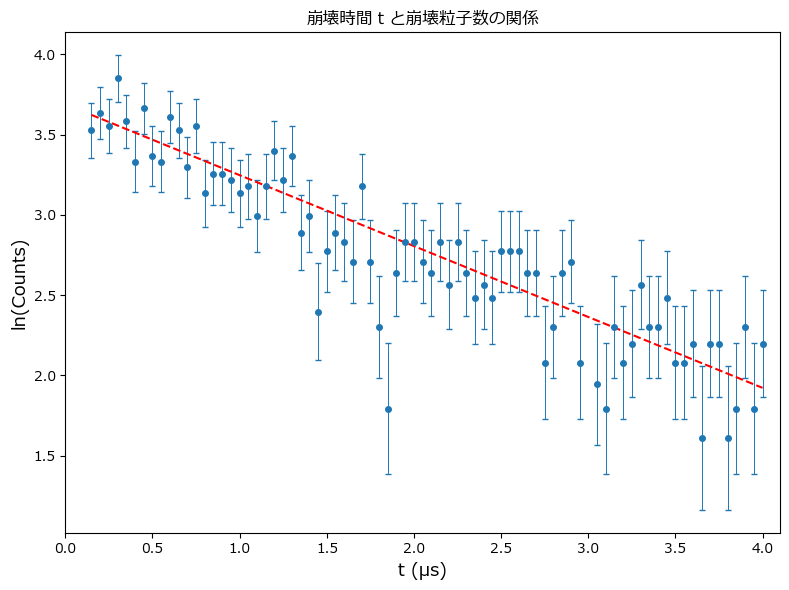

In [43]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# =====================
# 日本語フォント
# =====================

plt.rcParams["font.family"] = "Meiryo"

# 6/24(Elapsed time 33117)

counts = np.array([
2514,299,49,34,38,35,47,36,28,39,29,28,37,34,27,35,
23,26,26,25,23,24,20,24,30,25,29,18,20,11,16,18,
17,15,24,15,10,6,14,17,17,15,14,17,13,17,14,12,
13,12,16,16,16,14,14,8,10,14,15,8,4,7,6,10,
8,9,13,10,10,12,8,8,9,5,9,9,5,6,10,6,
9,3,5,6,9,10,9,2,7,6,4,7,2,5,3,4,
3,5,7,2,7,6,5,2,3,7,2,3,3,2,1,2,
4,4,5,1,5,0,0,1,3,2,2,2,2,0,0,1,
1,1,5,2,2,1,6,3,3,1,2,3,2,1,1,1,
1,1,0,1,1,0,1,2,2,1,1,2,3,3,2,0,
2,2,1,1,2,1,0,3,1,1,0,2,0,0,0,1,
3,2,1,0,0,2,1,0,2,0,1,1,0,0,0,2,
1,0,0,0,0,0,0,1,0,0,0,1,0,0,0,2,
1,0,0,0,1,1,0,1,0,0,1,1,0,0,0,2,
0,1,0,0,0,3,0,1,0,0,1,0,0,1,1,0,
2,0,1,0,0,1,0,0,0,1,0,0,0,0,0,1
])

dt = 0.05      # μs

t = np.arange(len(counts))*dt

# -------- フィットに使う範囲 --------
mask = (counts >= 5) & (t >= 0.15) & (t <= 4.0)

x = t[mask]
N = counts[mask]

y = np.log(N)

# エラーバー
yerr = 1/np.sqrt(N)

# 重み付き最小二乗法（共分散行列も取得）
coef, cov = np.polyfit(
    x,
    y,
    1,
    w=np.sqrt(N),
    cov=True
)

a, b = coef

# 傾きと切片の誤差
sigma_a = np.sqrt(cov[0, 0])
sigma_b = np.sqrt(cov[1, 1])

# 平均寿命
tau = -1 / a

# 誤差伝播
sigma_tau = sigma_a / (a**2)

print(f"傾き a = {a:.5f} ± {sigma_a:.5f}")
print(f"切片 b = {b:.5f} ± {sigma_b:.5f}")
print(f"τ = {tau:.2f} ± {sigma_tau:.2f} μs")

# フィット直線
xx = np.linspace(0.15,4.0,200)
yy = a*xx+b

# ===========================
# 描画
# ===========================

plt.figure(figsize=(8,6))

plt.errorbar(
    x,
    y,
    yerr=yerr,
    fmt='o',
    markersize=4,
    capsize=2,
    elinewidth=0.7
)

plt.plot(
    xx,
    yy,
    '--',
    color='red',
    linewidth=1.5
)

plt.xlabel("t (μs)",fontsize=13)
plt.ylabel("ln(Counts)",fontsize=13)
plt.title("崩壊時間ｔと崩壊粒子数の関係")

plt.xlim(0,4.1)
plt.grid(False)


plt.tight_layout()
plt.show()

傾き a = -0.47061 ± 0.01617
切片 b = 4.67087 ± 0.02962
τ = 2.12 ± 0.07 μs


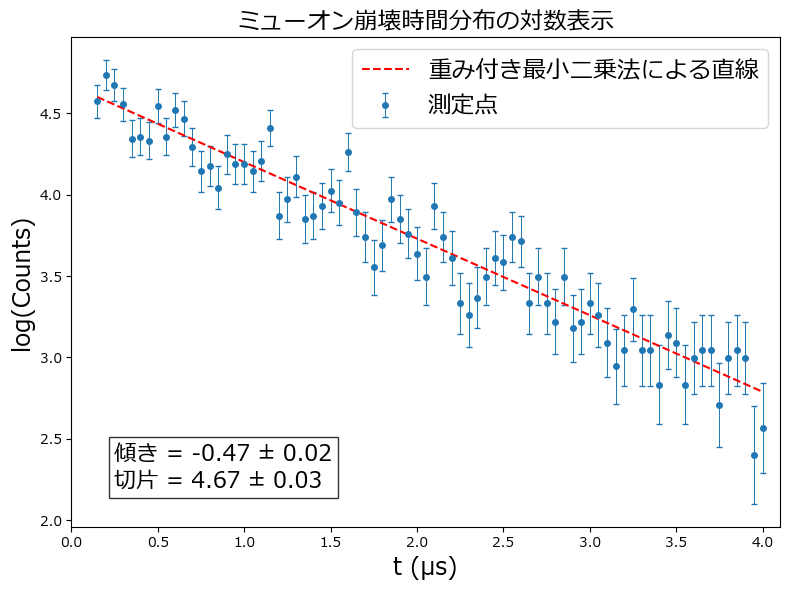

In [51]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# =====================
# 日本語フォント
# =====================

plt.rcParams["font.family"] = "Meiryo"

# 6/25(Elapsed time 86400)


counts = np.array([
6641,796,100,97,114,107,95,77,78,76,94,78,92,87,73,63,
65,57,70,66,66,63,67,82,48,53,61,47,48,51,56,52,
71,49,42,35,40,53,47,43,38,33,51,42,37,28,26,29,
33,37,36,42,41,28,33,28,25,33,24,25,28,26,22,19,
21,27,21,21,17,23,22,17,20,21,21,15,20,21,20,11,
13,18,17,19,14,13,17,10,8,13,12,6,12,13,9,14,
18,19,12,9,6,7,5,7,8,7,10,6,9,7,4,4,
6,5,8,9,7,11,13,14,5,9,3,3,9,7,6,4,
5,6,7,5,7,5,6,9,5,4,2,3,5,2,3,3,
6,3,4,5,8,5,4,6,1,3,3,7,3,6,3,3,
2,0,6,3,2,5,1,0,10,2,1,1,4,1,2,2,
3,2,3,0,2,0,1,5,0,2,1,2,2,1,3,0,
6,0,1,2,1,0,0,3,0,2,0,0,2,2,2,0,
1,1,4,3,2,1,0,0,0,2,3,2,0,0,2,1,
0,2,1,2,1,3,5,1,2,1,3,2,1,1,0,0,
0,1,2,0,0,0,1,2,0,0,2,2,1,1,1,2
])

dt = 0.05      # μs

t = np.arange(len(counts))*dt

# -------- フィットに使う範囲 --------
mask = (counts >= 5) & (t >= 0.15) & (t <= 4.0)

x = t[mask]
N = counts[mask]

y = np.log(N)

# エラーバー
yerr = 1/np.sqrt(N)

# 重み付き最小二乗法（共分散行列も取得）
coef, cov = np.polyfit(
    x,
    y,
    1,
    w=np.sqrt(N),
    cov=True
)

a, b = coef

# 傾きと切片の誤差
sigma_a = np.sqrt(cov[0, 0])
sigma_b = np.sqrt(cov[1, 1])

# 平均寿命
tau = -1 / a

# 誤差伝播
sigma_tau = sigma_a / (a**2)

print(f"傾き a = {a:.5f} ± {sigma_a:.5f}")
print(f"切片 b = {b:.5f} ± {sigma_b:.5f}")
print(f"τ = {tau:.2f} ± {sigma_tau:.2f} μs")

# フィット直線
xx = np.linspace(0.15,4.0,200)
yy = a*xx+b

# ===========================
# 描画
# ===========================

plt.figure(figsize=(8,6))

plt.errorbar(
    x,
    y,
    yerr=yerr,
    fmt='o',
    markersize=4,
    capsize=2,
    elinewidth=0.7,
    label='測定点'
)

plt.plot(
    xx,
    yy,
    '--',
    color='red',
    linewidth=1.5,
    label='重み付き最小二乗法による直線'
)

plt.xlabel("t (μs)",fontsize=17)
plt.ylabel("log(Counts)",fontsize=17)
plt.title("ミューオン崩壊時間分布の対数表示",fontsize=17)
plt.legend(loc='upper right', fontsize=17, frameon=True)

plt.xlim(0,4.1)
plt.grid(False)
plt.text(
    0.25,
    2.2,
    f"傾き = {a:.2f} ± {sigma_a:.2f}\n"
    f"切片 = {b:.2f} ± {sigma_b:.2f}",
    fontsize=16,
    bbox=dict(facecolor="white", edgecolor="black", alpha=0.8)
)
plt.tight_layout()
plt.show()

傾き a = -0.49499 ± 0.02788
切片 b = 3.64419 ± 0.04810
τ = 2.02 ± 0.11 μs


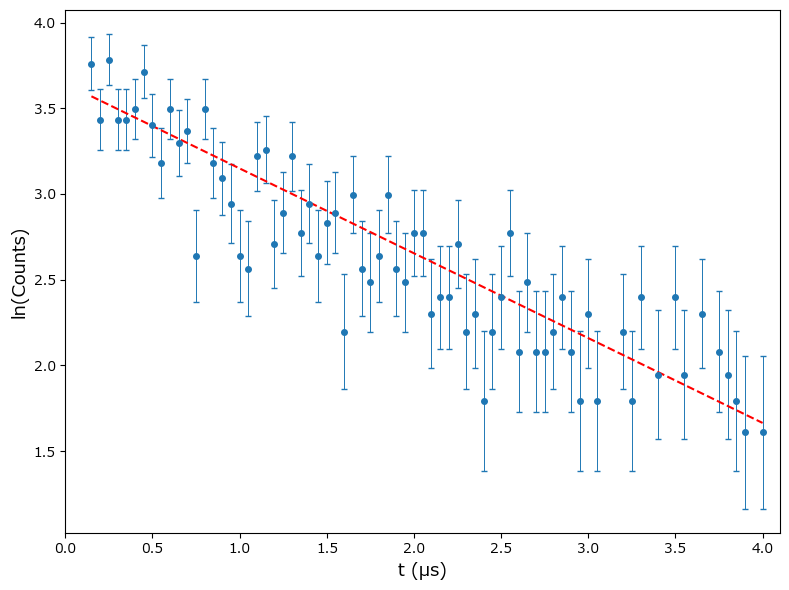

In [44]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# =====================
# 日本語フォント
# =====================

plt.rcParams["font.family"] = "Meiryo"

# 6/26(Elapsed time 27809)

counts = np.array([
2094,230,26,43,31,44,31,31,33,41,30,24,33,27,29,14,
33,24,22,19,14,13,25,26,15,18,25,16,19,14,17,18,
9,20,13,12,14,20,13,12,16,16,10,11,11,15,9,10,
6,9,11,16,8,12,8,8,9,11,8,6,10,6,3,4,
9,6,11,4,7,4,11,7,4,10,4,8,7,6,5,1,
5,5,6,5,5,4,6,5,1,1,9,3,3,3,5,4,
4,5,5,2,6,5,4,3,4,3,6,4,1,4,1,1,
1,3,4,2,4,1,3,2,1,0,2,1,2,1,0,0,
0,1,3,3,0,1,4,3,1,4,2,1,2,1,3,1,
1,1,0,1,0,1,1,0,2,0,1,1,1,2,0,0,
2,0,0,0,0,1,1,1,0,0,0,0,0,0,0,1,
2,1,1,1,0,0,0,0,1,1,1,0,2,1,1,0,
1,1,0,0,0,1,0,0,1,0,0,0,0,1,1,0,
0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,
0,1,0,1,0,1,2,1,0,2,0,0,0,1,1,0,
1,2,0,0,0,0,0,0,0,1,0,0,0,0,0,0
])

dt = 0.05      # μs

t = np.arange(len(counts))*dt

# -------- フィットに使う範囲 --------
mask = (counts >= 5) & (t >= 0.15) & (t <= 4.0)

x = t[mask]
N = counts[mask]

y = np.log(N)

# エラーバー
yerr = 1/np.sqrt(N)

# 重み付き最小二乗法（共分散行列も取得）
coef, cov = np.polyfit(
    x,
    y,
    1,
    w=np.sqrt(N),
    cov=True
)

a, b = coef

# 傾きと切片の誤差
sigma_a = np.sqrt(cov[0, 0])
sigma_b = np.sqrt(cov[1, 1])

# 平均寿命
tau = -1 / a

# 誤差伝播
sigma_tau = sigma_a / (a**2)

print(f"傾き a = {a:.5f} ± {sigma_a:.5f}")
print(f"切片 b = {b:.5f} ± {sigma_b:.5f}")
print(f"τ = {tau:.2f} ± {sigma_tau:.2f} μs")

# フィット直線
xx = np.linspace(0.15,4.0,200)
yy = a*xx+b

# ===========================
# 描画
# ===========================

plt.figure(figsize=(8,6))

plt.errorbar(
    x,
    y,
    yerr=yerr,
    fmt='o',
    markersize=4,
    capsize=2,
    elinewidth=0.7
)

plt.plot(
    xx,
    yy,
    '--',
    color='red',
    linewidth=1.5
)

plt.xlabel("t (μs)",fontsize=13)
plt.ylabel("ln(Counts)",fontsize=13)

plt.xlim(0,4.1)
plt.grid(False)

plt.tight_layout()
plt.show()

傾き a = -0.47917 ± 0.01800
切片 b = 4.74486 ± 0.03283
τ = 2.09 ± 0.08 μs


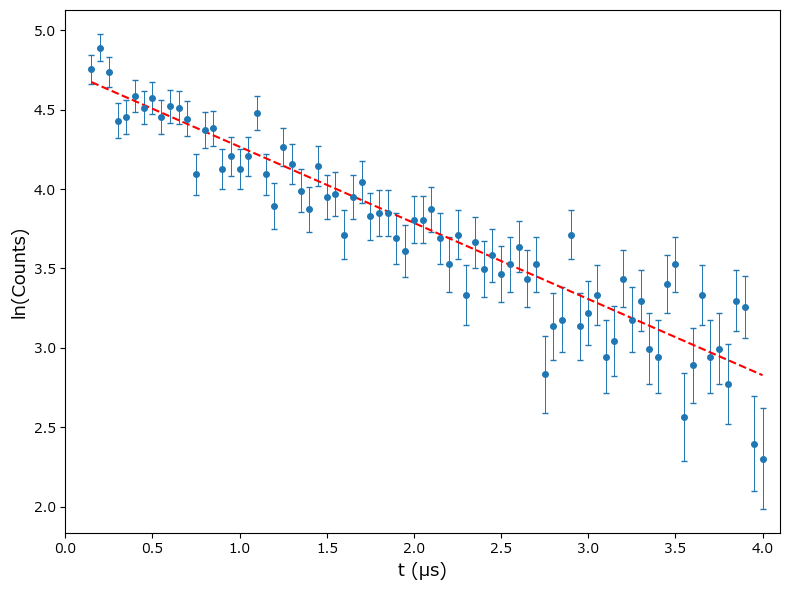

In [45]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# =====================
# 日本語フォント
# =====================

plt.rcParams["font.family"] = "Meiryo"

# 6/27(Elapsed time 86400)

counts = np.array([
6511,772,125,116,133,114,84,86,98,91,97,86,92,91,85,60,
79,80,62,67,62,67,88,60,49,71,64,54,48,63,52,53,
41,52,57,46,47,47,40,37,45,45,48,40,34,41,28,39,
33,36,32,34,38,31,34,17,23,24,41,23,25,28,19,21,
31,24,27,20,19,30,34,13,18,28,19,20,16,27,26,11,
10,19,17,12,13,16,18,11,14,11,16,13,9,14,9,9,
18,6,11,10,9,8,9,10,5,10,10,3,8,7,12,10,
9,7,11,9,13,5,5,5,5,7,7,3,10,7,7,6,
8,6,6,3,4,5,6,7,4,6,3,7,6,2,1,3,
7,2,3,6,3,9,6,3,3,3,3,4,5,3,1,2,
2,1,2,4,2,0,7,5,2,2,3,3,1,2,0,1,
0,2,2,2,0,2,2,2,2,3,4,1,2,1,0,2,
2,3,2,1,1,4,1,2,1,0,1,1,2,1,2,1,
1,2,2,0,1,3,0,1,1,1,2,4,0,1,3,1,
0,0,0,2,0,1,2,1,1,1,1,0,0,0,2,2,
0,0,3,1,1,1,1,1,0,1,1,2,0,0,0,0
])

dt = 0.05      # μs

t = np.arange(len(counts))*dt

# -------- フィットに使う範囲 --------
mask = (counts >= 5) & (t >= 0.15) & (t <= 4.0)

x = t[mask]
N = counts[mask]

y = np.log(N)

# エラーバー
yerr = 1/np.sqrt(N)

# 重み付き最小二乗法（共分散行列も取得）
coef, cov = np.polyfit(
    x,
    y,
    1,
    w=np.sqrt(N),
    cov=True
)

a, b = coef

# 傾きと切片の誤差
sigma_a = np.sqrt(cov[0, 0])
sigma_b = np.sqrt(cov[1, 1])

# 平均寿命
tau = -1 / a

# 誤差伝播
sigma_tau = sigma_a / (a**2)

print(f"傾き a = {a:.5f} ± {sigma_a:.5f}")
print(f"切片 b = {b:.5f} ± {sigma_b:.5f}")
print(f"τ = {tau:.2f} ± {sigma_tau:.2f} μs")

# フィット直線
xx = np.linspace(0.15,4.0,200)
yy = a*xx+b

# ===========================
# 描画
# ===========================

plt.figure(figsize=(8,6))

plt.errorbar(
    x,
    y,
    yerr=yerr,
    fmt='o',
    markersize=4,
    capsize=2,
    elinewidth=0.7
)

plt.plot(
    xx,
    yy,
    '--',
    color='red',
    linewidth=1.5
)

plt.xlabel("t (μs)",fontsize=13)
plt.ylabel("ln(Counts)",fontsize=13)

plt.xlim(0,4.1)
plt.grid(False)

plt.tight_layout()
plt.show()

傾き a = -0.46540 ± 0.01542
切片 b = 4.65647 ± 0.02843
τ = 2.15 ± 0.07 μs


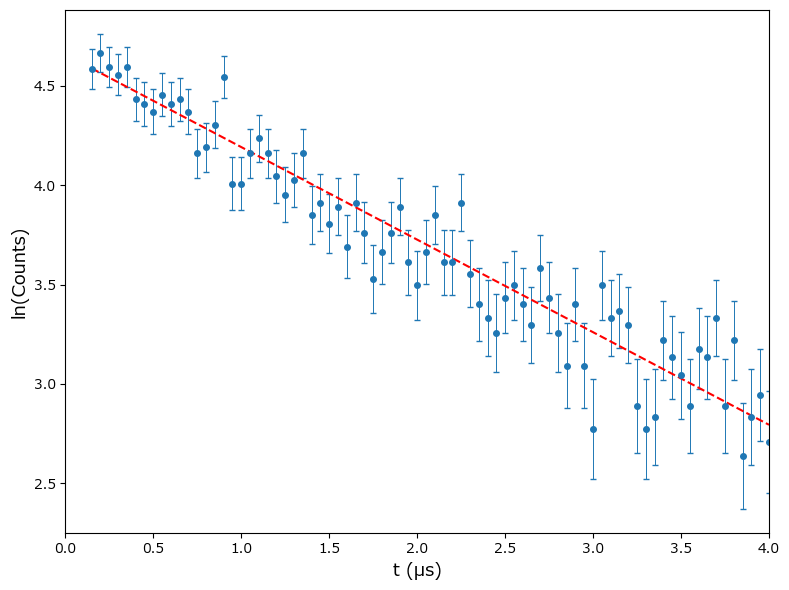

In [46]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# =====================
# 日本語フォント
# =====================

plt.rcParams["font.family"] = "Meiryo"

#6/28(Elapsed time 86400)

counts = np.array([
6351,718,124,98,106,99,95,99,84,82,79,86,82,84,79,64,
66,74,94,55,55,64,69,64,57,52,56,64,47,50,45,49,
40,50,43,34,39,43,49,37,33,39,47,37,37,50,35,30,
28,26,31,33,30,27,36,31,26,22,30,22,16,33,28,29,
27,18,16,17,25,23,21,18,24,23,28,18,25,14,17,19,
15,17,14,11,19,16,22,13,8,11,17,8,8,13,13,14,
10,8,9,11,6,10,9,7,8,11,9,9,8,5,15,11,
6,10,9,6,6,6,11,7,7,6,2,5,8,13,4,8,
5,1,6,3,7,3,2,7,4,3,4,6,3,4,4,4,
0,3,4,3,5,5,4,1,4,4,3,4,6,3,1,0,
5,3,1,1,2,4,0,2,2,2,2,2,1,4,2,2,
0,5,1,1,2,1,6,2,1,2,2,2,0,1,0,0,
2,4,1,1,1,2,4,1,6,4,0,1,3,4,4,0,
1,3,1,0,2,2,0,5,0,0,2,2,3,0,1,0,
1,1,0,4,3,1,1,4,1,3,2,2,0,2,1,3,
2,3,1,1,1,0,0,0,2,1,1,2,1,4,1,1
])

dt = 0.05      # μs

t = np.arange(len(counts))*dt

# -------- フィットに使う範囲 --------
mask = (counts >= 5) & (t >= 0.15) & (t <= 4.0)

x = t[mask]
N = counts[mask]

y = np.log(N)

# エラーバー
yerr = 1/np.sqrt(N)

# 重み付き最小二乗法（共分散行列も取得）
coef, cov = np.polyfit(
    x,
    y,
    1,
    w=np.sqrt(N),
    cov=True
)

a, b = coef

# 傾きと切片の誤差
sigma_a = np.sqrt(cov[0, 0])
sigma_b = np.sqrt(cov[1, 1])

# 平均寿命
tau = -1 / a

# 誤差伝播
sigma_tau = sigma_a / (a**2)

print(f"傾き a = {a:.5f} ± {sigma_a:.5f}")
print(f"切片 b = {b:.5f} ± {sigma_b:.5f}")
print(f"τ = {tau:.2f} ± {sigma_tau:.2f} μs")

# フィット直線
xx = np.linspace(0.15,4.0,200)
yy = a*xx+b

# ===========================
# 描画
# ===========================

plt.figure(figsize=(8,6))

plt.errorbar(
    x,
    y,
    yerr=yerr,
    fmt='o',
    markersize=4,
    capsize=2,
    elinewidth=0.7
)

plt.plot(
    xx,
    yy,
    '--',
    color='red',
    linewidth=1.5
)

plt.xlabel("t (μs)",fontsize=13)
plt.ylabel("ln(Counts)",fontsize=13)

plt.xlim(0,4)
plt.grid(False)

plt.tight_layout()
plt.show()

傾き a = -0.43871 ± 0.01682
切片 b = 4.61809 ± 0.03134
τ = 2.28 ± 0.09 μs


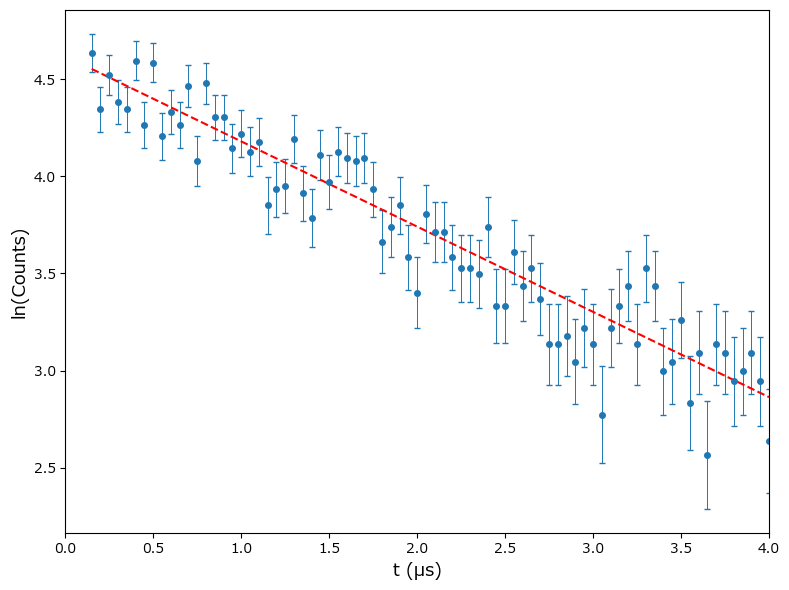

In [47]:
import numpy as np
import matplotlib.pyplot as plt

# 6/29(Elapsed time 86400)

counts = np.array([
6170,795,96,103,77,92,80,77,99,71,98,67,76,71,87,59,
88,74,74,63,68,62,65,47,51,52,66,50,44,61,53,62,
60,59,60,51,39,42,47,36,30,45,41,41,36,34,34,33,
42,28,28,37,31,34,29,23,23,24,21,25,23,16,25,28,
31,23,34,31,20,21,26,17,22,13,23,22,19,20,22,19,
14,14,17,17,16,10,10,12,18,11,15,17,16,17,12,16,
13,12,14,8,4,10,11,9,5,9,5,14,5,7,8,7,
7,7,6,9,11,6,4,6,5,6,4,3,7,2,10,4,
2,3,6,8,4,4,7,3,5,2,4,7,4,1,5,3,
4,4,3,2,2,3,6,7,0,1,8,2,4,3,5,0,
4,5,4,2,2,2,3,3,6,4,2,2,5,3,2,2,
3,0,1,1,1,3,1,1,1,0,1,2,2,1,0,2,
1,2,1,1,1,3,2,2,0,1,2,3,0,1,1,2,
0,3,2,0,1,2,2,0,3,2,0,2,0,0,1,2,
0,2,0,0,1,0,0,2,1,1,1,0,0,3,3,0,
4,1,1,0,1,1,0,2,2,1,0,0,1,0,2,0
])

dt = 0.05      # μs

t = np.arange(len(counts))*dt

# -------- フィットに使う範囲 --------
mask = (counts >= 5) & (t >= 0.15) & (t <= 4.0)

x = t[mask]
N = counts[mask]

y = np.log(N)

# エラーバー
yerr = 1/np.sqrt(N)

# 重み付き最小二乗法（共分散行列も取得）
coef, cov = np.polyfit(
    x,
    y,
    1,
    w=np.sqrt(N),
    cov=True
)

a, b = coef

# 傾きと切片の誤差
sigma_a = np.sqrt(cov[0, 0])
sigma_b = np.sqrt(cov[1, 1])

# 平均寿命
tau = -1 / a

# 誤差伝播
sigma_tau = sigma_a / (a**2)

print(f"傾き a = {a:.5f} ± {sigma_a:.5f}")
print(f"切片 b = {b:.5f} ± {sigma_b:.5f}")
print(f"τ = {tau:.2f} ± {sigma_tau:.2f} μs")

# フィット直線
xx = np.linspace(0.15,4.0,200)
yy = a*xx+b

# ===========================
# 描画
# ===========================

plt.figure(figsize=(8,6))

plt.errorbar(
    x,
    y,
    yerr=yerr,
    fmt='o',
    markersize=4,
    capsize=2,
    elinewidth=0.7
)

plt.plot(
    xx,
    yy,
    '--',
    color='red',
    linewidth=1.5
)

plt.xlabel("t (μs)",fontsize=13)
plt.ylabel("ln(Counts)",fontsize=13)

plt.xlim(0,4)
plt.grid(False)

plt.tight_layout()
plt.show()

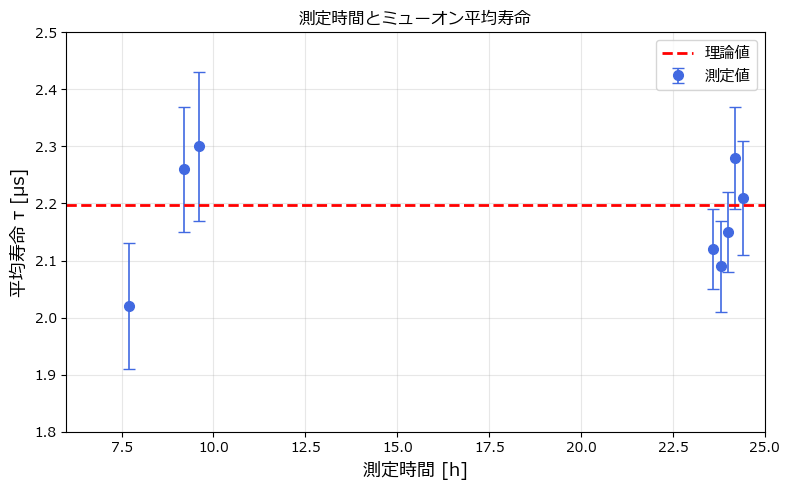

In [57]:
import numpy as np
import matplotlib.pyplot as plt

# 日本語フォント
plt.rcParams["font.family"] = "Meiryo"

# 測定時間[h]（24時間のデータは少しだけずらす）
time = np.array([9.2, 23.6, 7.7, 23.8, 24.0, 24.2, 9.6, 24.4])

# 平均寿命
tau = np.array([2.26, 2.12, 2.02, 2.09, 2.15, 2.28, 2.30, 2.21])

# 誤差
err = np.array([0.11, 0.07, 0.11, 0.08, 0.07, 0.09, 0.13, 0.10])

# 理論値
tau_theory = 2.196980

plt.figure(figsize=(8,5))

# エラーバー付き散布図
plt.errorbar(
    time,
    tau,
    yerr=err,
    fmt='o',
    markersize=7,
    capsize=4,
    elinewidth=1.2,
    color='royalblue',
    label='測定値'
)

# 理論値
plt.axhline(
    tau_theory,
    color='red',
    linestyle='--',
    linewidth=2,
    label='理論値'
)

plt.xlabel("測定時間 [h]", fontsize=13)
plt.ylabel("平均寿命 τ [μs]", fontsize=13)
plt.title("測定時間とミューオン平均寿命")

plt.xlim(6, 25)
plt.ylim(1.8, 2.5)

plt.grid(alpha=0.3)
plt.legend(fontsize=11)

plt.tight_layout()
plt.show()

傾き a = -0.43495 ± 0.02380
切片 b = 3.66630 ± 0.04474
τ = 2.30 ± 0.13 μs


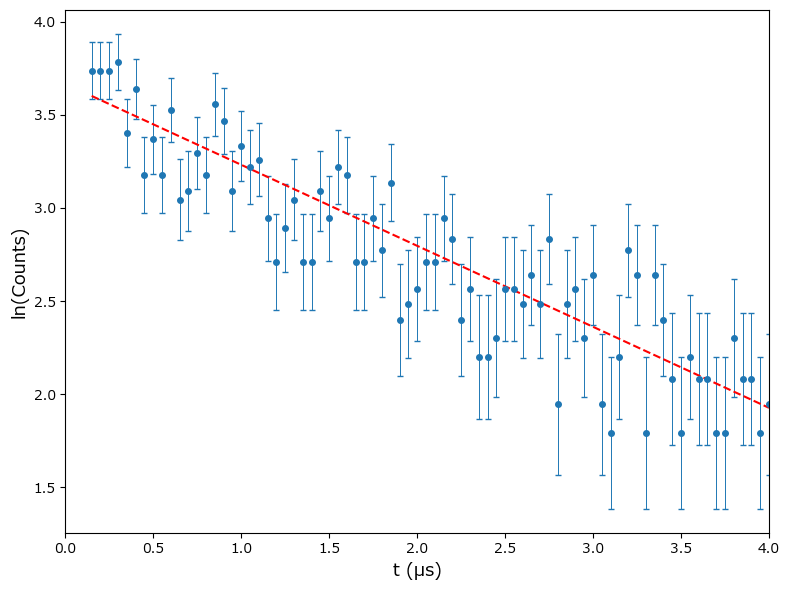

In [49]:
import numpy as np
import matplotlib.pyplot as plt

# 6/30はデータがとれなかった,7/1のデータ(Elapsed time 34383)

counts = np.array([
2592,332,42,42,42,42,44,30,38,24,29,24,34,21,22,27,
24,35,32,22,28,25,26,19,15,18,21,15,15,22,19,25,
24,15,15,19,16,23,11,12,13,15,15,19,17,11,13,9,
9,10,13,13,12,14,12,17,7,12,13,10,14,7,6,9,
16,14,6,14,11,8,6,9,8,8,6,6,10,8,8,6,
7,4,7,6,5,2,3,3,6,7,5,5,9,7,2,4,
8,4,1,5,4,7,4,3,3,7,5,5,3,1,4,2,
1,3,3,2,1,1,3,4,6,0,0,0,1,1,3,3,
3,3,4,2,4,0,1,1,2,0,2,1,2,1,1,2,
1,2,2,1,2,0,1,1,2,0,1,3,0,0,0,0,
2,0,2,1,1,4,0,0,0,0,0,1,1,0,2,0,
0,3,1,1,1,1,0,1,0,0,0,0,1,0,1,0,
0,0,0,1,0,0,1,1,0,1,0,0,0,3,0,0,
0,0,1,0,0,0,1,1,0,1,1,0,0,0,0,0,
1,0,0,0,1,0,1,0,0,1,0,0,0,0,0,1,
0,1,3,0,0,0,1,1,0,0,1,0,0,0,0,0
])

dt = 0.05      # μs

t = np.arange(len(counts))*dt

# -------- フィットに使う範囲 --------
mask = (counts >= 5) & (t >= 0.15) & (t <= 4.0)

x = t[mask]
N = counts[mask]

y = np.log(N)

# エラーバー
yerr = 1/np.sqrt(N)

# 重み付き最小二乗法（共分散行列も取得）
coef, cov = np.polyfit(
    x,
    y,
    1,
    w=np.sqrt(N),
    cov=True
)

a, b = coef

# 傾きと切片の誤差
sigma_a = np.sqrt(cov[0, 0])
sigma_b = np.sqrt(cov[1, 1])

# 平均寿命
tau = -1 / a

# 誤差伝播
sigma_tau = sigma_a / (a**2)

print(f"傾き a = {a:.5f} ± {sigma_a:.5f}")
print(f"切片 b = {b:.5f} ± {sigma_b:.5f}")
print(f"τ = {tau:.2f} ± {sigma_tau:.2f} μs")

# フィット直線
xx = np.linspace(0.15,4.0,200)
yy = a*xx+b

# ===========================
# 描画
# ===========================

plt.figure(figsize=(8,6))

plt.errorbar(
    x,
    y,
    yerr=yerr,
    fmt='o',
    markersize=4,
    capsize=2,
    elinewidth=0.7
)

plt.plot(
    xx,
    yy,
    '--',
    color='red',
    linewidth=1.5
)

plt.xlabel("t (μs)",fontsize=13)
plt.ylabel("ln(Counts)",fontsize=13)

plt.xlim(0,4)
plt.grid(False)

plt.tight_layout()
plt.show()

傾き a = -0.45338 ± 0.02017
切片 b = 4.04418 ± 0.03730
τ = 2.21 ± 0.10 μs


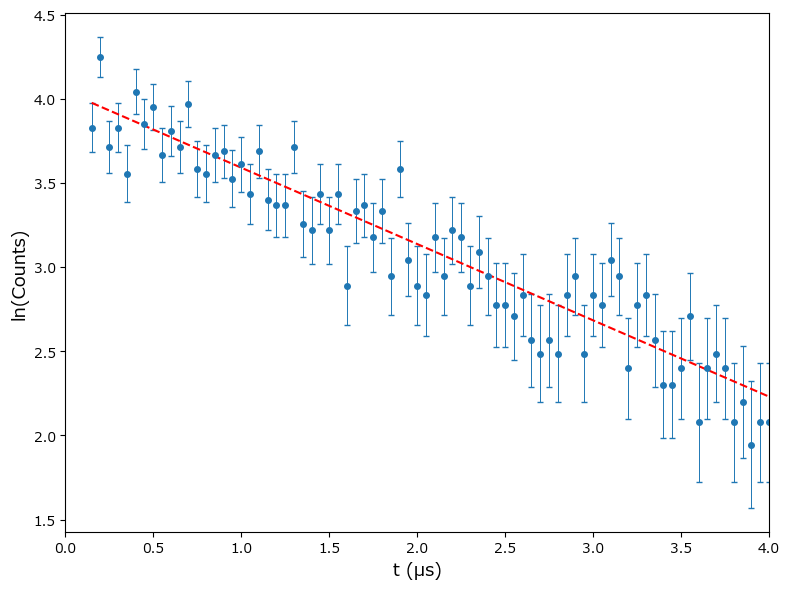

In [50]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# =====================
# 日本語フォント
# =====================

plt.rcParams["font.family"] = "Meiryo"

#6/28(Elapsed time 86400)

counts =  np.array([
3580, 484, 61, 46, 70, 41, 46, 35, 57, 47, 52, 39, 45, 41, 53, 36,
35, 39, 40, 34, 37, 31, 40, 30, 29, 29, 41, 26, 25, 31, 25, 31,
18, 28, 29, 24, 28, 19, 36, 21, 18, 17, 24, 19, 25, 24, 18, 22,
19, 16, 16, 15, 17, 13, 12, 13, 12, 17, 19, 12, 17, 16, 21, 19,
11, 16, 17, 13, 10, 10, 11, 15, 8, 11, 12, 11, 8, 9, 7, 8,
8, 12, 7, 9, 7, 8, 9, 4, 5, 8, 9, 6, 4, 4, 9, 11,
7, 7, 6, 6, 8, 8, 4, 5, 5, 6, 10, 6, 3, 6, 8, 5,
6, 6, 5, 8, 2, 4, 2, 2, 1, 2, 2, 1, 3, 2, 3, 5,
2, 3, 5, 2, 0, 0, 4, 3, 1, 2, 3, 3, 4, 4, 2, 4,
2, 3, 3, 3, 6, 4, 2, 1, 3, 2, 2, 1, 0, 2, 1, 3,
1, 1, 1, 0, 1, 2, 1, 1, 1, 0, 2, 1, 1, 1, 0, 0,
2, 1, 2, 1, 2, 0, 1, 0, 0, 0, 3, 0, 1, 0, 0, 0,
0, 0, 0, 0, 0, 1, 3, 2, 2, 1, 0, 0, 0, 1, 0, 0,
0, 1, 1, 0, 0, 0, 1, 3, 0, 0, 1, 1, 1, 1, 2, 0,
1, 2, 1, 0, 0, 0, 2, 0, 0, 2, 0, 1, 0, 1, 0, 1,
2, 2, 1, 2, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0
])


dt = 0.05      # μs

t = np.arange(len(counts))*dt

# -------- フィットに使う範囲 --------
mask = (counts >= 5) & (t >= 0.15) & (t <= 4.0)

x = t[mask]
N = counts[mask]

y = np.log(N)

# エラーバー
yerr = 1/np.sqrt(N)

# 重み付き最小二乗法（共分散行列も取得）
coef, cov = np.polyfit(
    x,
    y,
    1,
    w=np.sqrt(N),
    cov=True
)

a, b = coef

# 傾きと切片の誤差
sigma_a = np.sqrt(cov[0, 0])
sigma_b = np.sqrt(cov[1, 1])

# 平均寿命
tau = -1 / a

# 誤差伝播
sigma_tau = sigma_a / (a**2)

print(f"傾き a = {a:.5f} ± {sigma_a:.5f}")
print(f"切片 b = {b:.5f} ± {sigma_b:.5f}")
print(f"τ = {tau:.2f} ± {sigma_tau:.2f} μs")

# フィット直線
xx = np.linspace(0.15,4.0,200)
yy = a*xx+b

# ===========================
# 描画
# ===========================

plt.figure(figsize=(8,6))

plt.errorbar(
    x,
    y,
    yerr=yerr,
    fmt='o',
    markersize=4,
    capsize=2,
    elinewidth=0.7
)

plt.plot(
    xx,
    yy,
    '--',
    color='red',
    linewidth=1.5
)

plt.xlabel("t (μs)",fontsize=13)
plt.ylabel("ln(Counts)",fontsize=13)

plt.xlim(0,4)
plt.grid(False)

plt.tight_layout()
plt.show()

In [55]:
import numpy as np

# 実験値 [μs]
tau_exp = np.array([
    2.26,
    2.12,
    2.02,
    2.09,
    2.15,
    2.28,
    2.28,
    2.30,
    2.21
])

# 理論値 [μs]
tau_theory = 2.196980

# 相対誤差（%）
relative_error = np.abs(tau_exp - tau_theory) / tau_theory * 100

# 表示
for i, err in enumerate(relative_error, start=1):
    print(f"測定{i}: {err:.2f} %")

測定1: 2.87 %
測定2: 3.50 %
測定3: 8.06 %
測定4: 4.87 %
測定5: 2.14 %
測定6: 3.78 %
測定7: 3.78 %
測定8: 4.69 %
測定9: 0.59 %


In [56]:
import numpy as np

# 実験値 [μs]
tau = np.array([
    2.26,
    2.12,
    2.02,
    2.09,
    2.15,
    2.28,
    2.28,
    2.30,
    2.21
])

# 各測定の誤差 [μs]
sigma = np.array([
    0.11,
    0.07,
    0.11,
    0.08,
    0.07,
    0.09,
    0.09,
    0.13,
    0.10
])

# 理論値 [μs]
tau_theory = 2.196980

# 重み
w = 1 / sigma**2

# 重み付き平均
tau_mean = np.sum(w * tau) / np.sum(w)

# 平均の誤差
sigma_mean = 1 / np.sqrt(np.sum(w))

# 相対誤差
relative_error = abs(tau_mean - tau_theory) / tau_theory * 100

print(f"平均寿命 = {tau_mean:.2f} ± {sigma_mean:.3f} μs")
print(f"相対誤差 = {relative_error:.2f} %")

平均寿命 = 2.18 ± 0.030 μs
相対誤差 = 0.94 %
